In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('powerplant_ds.csv')
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [4]:
X = df.drop(columns=['PE'])
y = df['PE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)



In [7]:
type(X_train_scaled)

numpy.ndarray

In [8]:
type(y_train)

pandas.core.series.Series

In [9]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [10]:
# ANN Model Definition

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6,1),
        )

    def forward(self, x):
        x = self.model(x)
        return x 

In [11]:
import torch.optim as optim

model = ANN()

# loss, Optimiser
criterion = nn.MSELoss()
optimiser = optim.Adam(model.parameters())

In [12]:
# Training Model 

train_losses = []
val_losses = []
best_val_loss = float('inf')

epochs = 60

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for xb, yb in train_loader:
        optimiser.zero_grad()
        
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimiser.step()
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()
    
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f'Epoch {epoch+1}/{epochs} => train loss = {epoch_train_loss} and val loss = {epoch_val_loss}')

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_model.pt') # .pt or .pth

Epoch 1/60 => train loss = 206069.15716145834 and val loss = 203174.17395833333
Epoch 2/60 => train loss = 192735.59830729166 and val loss = 176617.87473958332
Epoch 3/60 => train loss = 150092.658203125 and val loss = 120132.67265625
Epoch 4/60 => train loss = 88784.1677734375 and val loss = 60844.167708333334
Epoch 5/60 => train loss = 42631.95837402344 and val loss = 30378.448404947918
Epoch 6/60 => train loss = 25319.849450683592 and val loss = 22060.281494140625
Epoch 7/60 => train loss = 20190.059564208983 and val loss = 18342.936686197918
Epoch 8/60 => train loss = 16848.684484863283 and val loss = 14993.169368489584
Epoch 9/60 => train loss = 13501.915889485677 and val loss = 11688.282356770833
Epoch 10/60 => train loss = 10275.79166056315 and val loss = 8571.185213216146
Epoch 11/60 => train loss = 7294.73129679362 and val loss = 5827.207092285156
Epoch 12/60 => train loss = 4784.432300313314 and val loss = 3656.684676106771
Epoch 13/60 => train loss = 2913.8617630004883 and v

Text(0, 0.5, 'Losses')

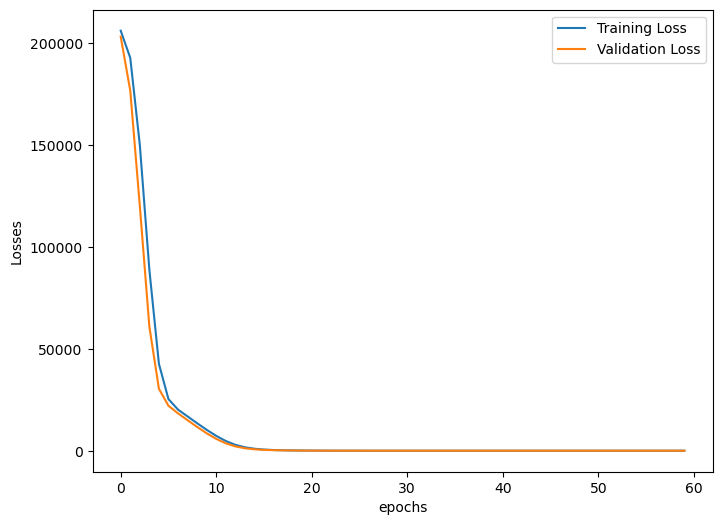

In [13]:
loss_df = pd.DataFrame({
    'train_loss' : train_losses,
    'val_loss' : val_losses
})

plt.figure(figsize=(8,6))
plt.plot(loss_df['train_loss'], label='Training Loss')
plt.plot(loss_df['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('Losses')

In [14]:
model.load_state_dict(torch.load('best_model.pt', weights_only=True))

<All keys matched successfully>

In [15]:
# Evaluation

model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)
    train_MSE = criterion(train_pred, y_train_tensor)
    test_MSE = criterion(test_pred, y_test_tensor)

print(f'Training MSE : {train_MSE.item()}')
print(f'Testing MSE : {test_MSE.item()}')

Training MSE : 20.767900466918945
Testing MSE : 19.221174240112305


In [16]:
from sklearn.metrics import r2_score

print(f'r2 score : {r2_score(y_test, test_pred)}')

r2 score : 0.9328269626137571


In [17]:
predicted_df = pd.DataFrame(test_pred.numpy(), columns=['Predicted Values'])
actual_df = pd.DataFrame(y_test.values, columns=['Actual Values'])

new_df = pd.concat([predicted_df, actual_df], axis=1)
new_df

,Predicted Values,Actual Values
0,435.101837,433.27
1,437.057556,438.16
2,461.545532,458.42
3,477.011261,480.82
4,434.845306,441.41
...,...,...
1909,451.839539,456.70
1910,431.529633,438.04
1911,468.125732,467.80
1912,430.943268,437.14
